# Exploratory Data Analysis (EDA): SME KT ZH Collaboration Forecasting
This notebook explores transaction-level sales data and its time-series structure, with the goal of understanding seasonality, customer heterogeneity, and whether holidays add predictive signal.

## What we analyze
- Overall sales activity over time (daily/weekly/monthly aggregations)
- Calendar effects: weekday / month / quarter patterns, plus multi-seasonal decomposition (MSTL)
- Segment differences (B2B vs. B2C)
- Customer ordering cadence (mean inter-order time and variability)
- Holiday signal (visual overlays + simple lagged correlation)
- Forecasting impact of holiday covariates using AutoGluon TimeSeries

## Main takeaways (from this EDA)
- Sales show clear calendar structure (weekday and longer-term seasonality), but variability is substantial.
- Customer ordering behavior is highly heterogeneous: some customers are regular, others are bursty/irregular.
- Holidays do not show a strong standalone signal at the daily level; any effect is small relative to typical fluctuations.
- Adding a simple holiday indicator (`is_holiday`) can help on average (capturing closures/low-activity periods), but best-model performance is similar with and without it across the tested settings.

In [1]:
import os.path as osp
from datetime import datetime

import numpy as np
import pandas as pd
import plotly.express as px
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

from sme_kt_zh_collaboration_forecasting import EDA as se
from sme_kt_zh_collaboration_forecasting import utils as su

/Users/oliver_sdsc/Documents/KT_ZH_SME/sme-kt-zh-collaboration-forecasting/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = su.read_sales_data()

## Basic transaction-level overview
Before moving to the aggregated time-series analysis, the plots below provide a compact view of the raw transaction data and how activity is distributed across customers and customer groups.

- The first two scatter plots place each order on a date-customer grid. One colors points by `customer_type`, and the other by `customer_cat`. These views show when orders occur, how concentrated activity is for specific customers, and whether different customer groups are spread evenly through time or cluster in particular periods.
- The histogram of `Customer Type` summarizes how many transactions fall into the main segments such as B2B, B2C, and Bund. This provides a quick sense of class balance and indicates which segment contributes most of the observed sales activity.
- The printed segment summary complements the plots by reporting the number of unique customers and the average number of orders per customer per year for B2B and B2C. This helps separate the effect of customer count from the effect of ordering frequency.

Together, these basic plots establish the raw data coverage, segment composition, and customer heterogeneity before the notebook moves into the broader sales EDA.

In [3]:
px.scatter(df, x="date", y="customer", color="customer_type", title="All Customers All Orders", width=1000)

In [4]:
px.scatter(df, x="date", y="customer", color="customer_cat", title="All Customers All Orders", width=1000)

In [5]:
df_plot = df.copy()
df_plot.columns = [
    "Customer Type" if column == "customer_type" else column
    for column in df_plot.columns
]

fig = px.histogram(
    df_plot,
    x="Customer Type",
    color="Customer Type",
    title="Number of Sales: B2B vs B2C vs Bund",
    width=800,
)
fig.show()

In [6]:
customers_b2c = len(df.loc[df["customer_type"] == "B-to-C", "customer"].unique())
orders_b2c = len(df.loc[df["customer_type"] == "B-to-C"])
customers_b2b = len(df.loc[df["customer_type"] == "B-to-B", "customer"].unique())
orders_b2b = len(df.loc[df["customer_type"] == "B-to-B"])

t_d = (df["date"].max() - df["date"].min()).days
years_d = t_d / 365.0

print(
    f"unique customers in b2b: {customers_b2b}, "
    f"with avg order per customer per year: {orders_b2b / customers_b2b / years_d:.2f}"
)
print(
    f"unique customers in b2c: {customers_b2c}, "
    f"with avg order per customer per year: {orders_b2c / customers_b2c / years_d:.2f}"
)

unique customers in b2b: 327, with avg order per customer per year: 4.77
unique customers in b2c: 96, with avg order per customer per year: 0.54


## General sales EDA
The function below converts the raw transaction table into a regular daily time series of transaction counts and then examines its calendar structure, seasonal patterns, and statistical properties.

- It first cleans the data, restricts the analysis window to the recent period, removes duplicate rows, and derives calendar features such as year, quarter, month, week, and weekday.
- It then aggregates transactions by day and reindexes the series so that days without sales are kept as zeros. This is important because the later plots and tests assume a continuous daily timeline.
- The box plots summarize how transaction counts vary by weekday, month, week of year, quarter, and year. Together, they show whether sales activity is systematically higher or lower in certain calendar periods and how variable that activity is within each group.
- The month-by-weekday heatmap shows the average daily transaction count for each calendar combination, making it easier to spot interactions such as stronger weekdays in specific months.
- The MSTL decomposition separates the daily series into trend, recurring seasonal components, and residual noise. This helps identify longer-term movement in demand as well as repeating weekly and annual structure.
- The weekly line plot by `customer_cat` compares transaction velocity across customer categories over time and shows whether segment-level activity moves together or follows different patterns.
- Finally, the ADF and KPSS tests, together with the ACF and PACF plots, assess how stationary the daily series is and how strongly it depends on recent lags. These diagnostics help inform downstream forecasting choices.

Overall, this section moves from descriptive calendar summaries to decomposition and statistical diagnostics, providing a broad view of seasonality, trend, segment behavior, and time-series dependence in the sales data.

--- Phase 1: Data Preprocessing ---
Removed 617 duplicate rows.
--- Phase 2: Feature Engineering ---


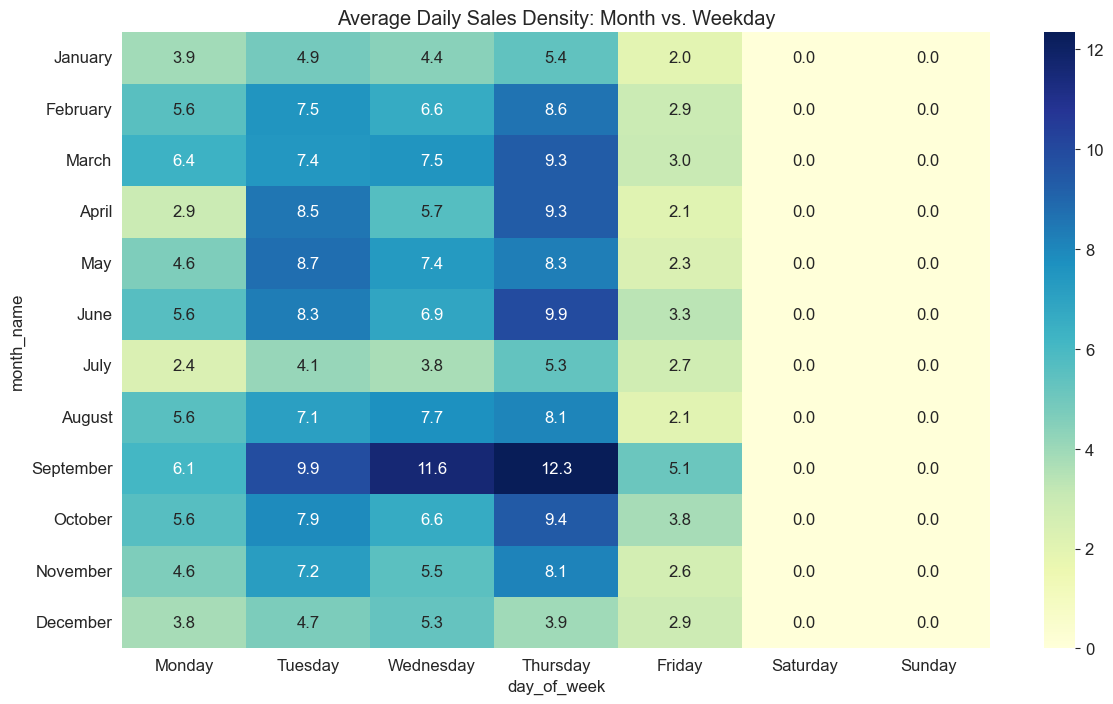

--- Phase 4: Multi-Seasonal Decomposition ---


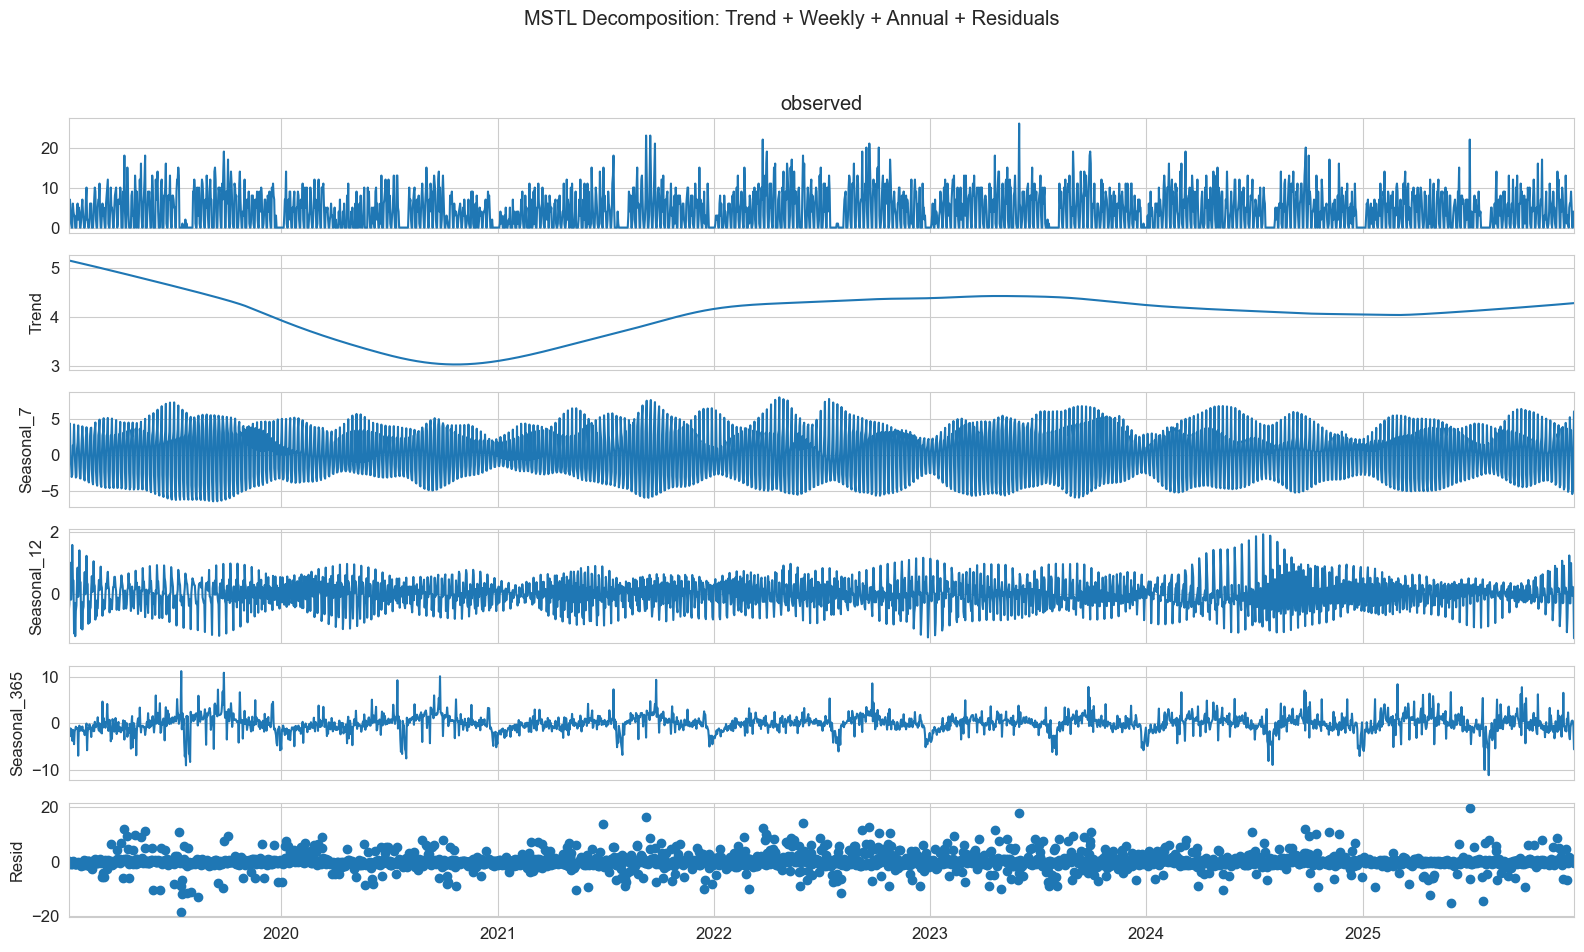

--- Phase 5: Categorical Segment Analysis ---


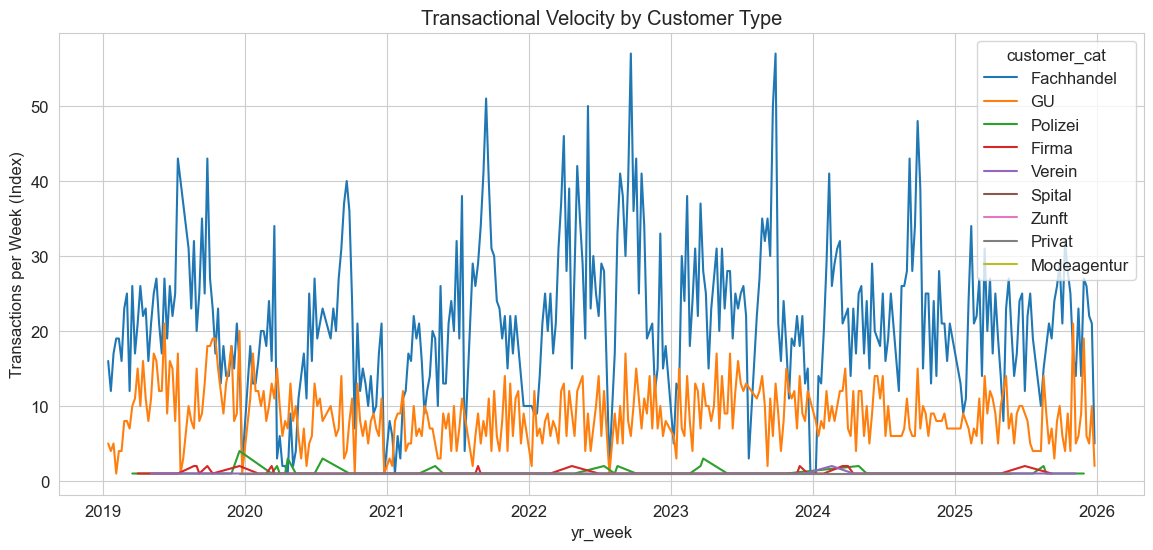

--- Phase 6: Statistical Stationarity Tests ---
ADF Statistic: -6.6552
p-value: 0.0000
Conclusion: Series is stationary at 5% significance.
KPSS statistic: 0.1882
KPSS p-value:   0.1000
KPSS lags:      61
KPSS critical:  {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Null hypothesis is not rejected: The distribution is stationary according to KPSS


/Users/oliver_sdsc/Documents/KT_ZH_SME/sme-kt-zh-collaboration-forecasting/src/sme_kt_zh_collaboration_forecasting/EDA.py:218: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




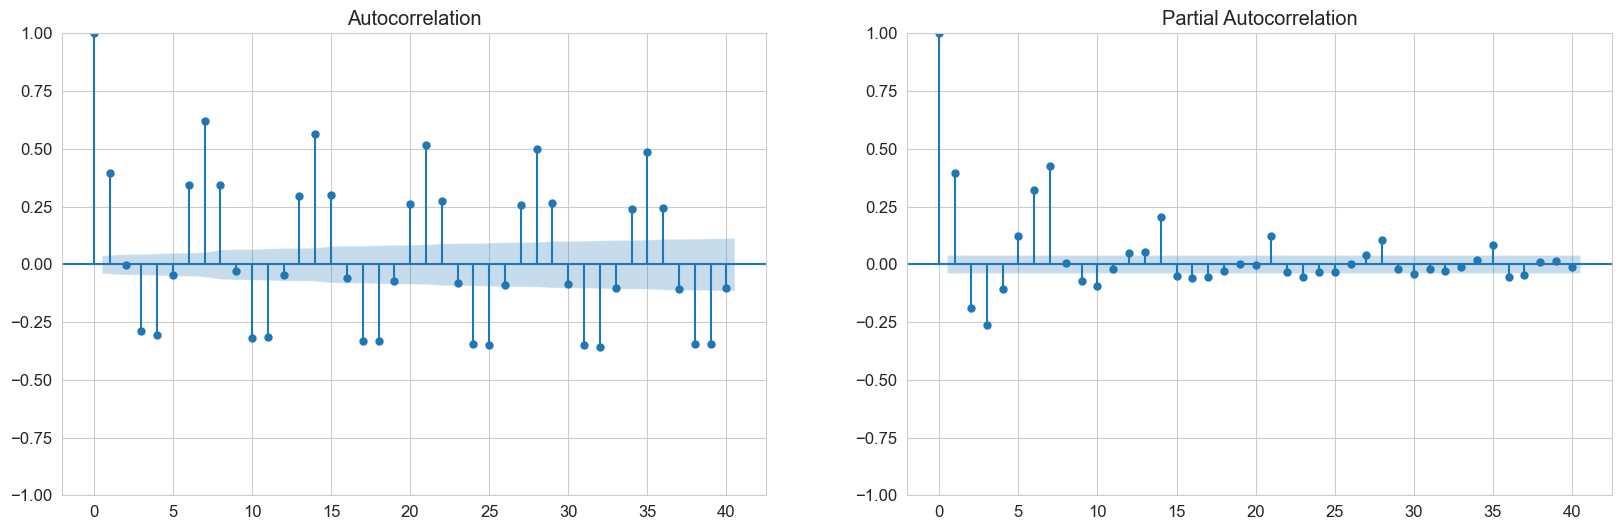

In [7]:
d_s, mstl, month_sr = se.perform_general_sales_eda(df)

## Segmenting by customer type
We split transactions into B2B and B2C to compare volume and seasonal structure. Because B2C has fewer observations, its patterns are noisier, so the interpretation below mainly reflects the stronger B2B signal. The commented code can be used to rerun the same general sales EDA separately for each segment.

In [8]:
bc_df = df.loc[df["customer_type"] == "B-to-C"].copy()
bb_df = df.loc[df["customer_type"] == "B-to-B"].copy()

# Uncomment to run the same EDA separately for B2C and B2B.
# _, _, _ = se.perform_general_sales_eda(bc_df)
# _, _, _ = se.perform_general_sales_eda(bb_df)

## Customer ordering cadence
We next examine how regularly customers place orders, using both the average time between orders and its variability.

Order frequency varies widely across customers, which makes aggregate demand harder to predict. The histogram below summarizes each customer's average inter-order time in days per order.

In [9]:
def plot_order_frequency(df):
    df = df.copy()
    df["first_order"] = df.groupby("customer")["date"].transform("min")
    df["last_order"] = df.groupby("customer")["date"].transform("max")
    df["n_orders"] = df.groupby("customer")["date"].transform("size")
    df["order_time_delta"] = df["last_order"] - df["first_order"]
    df["order_time_delta"] = df["order_time_delta"].dt.days
    df["order_frq"] = df["order_time_delta"] / df["n_orders"]
    df = df.loc[df["order_frq"] > 0]
    df_plot = df.groupby("customer")[["order_frq"]].mean().reset_index()

    fig = px.histogram(df_plot, x="order_frq", nbins=75)
    fig.update_layout(title="Order Frequency of Customers in Days per Order", width=900)
    fig.show()

plot_order_frequency(df)

The scatter plot below compares each customer's mean inter-order time with its standard deviation for customers with more than three orders. Points below the 45-degree line are relatively regular, while points above it are more bursty or irregular. B2B and B2C appear broadly similar, with no sharply separated clusters.

In [10]:
def plot_customer_type(df_int):
    df = df_int.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["customer", "date"])
    df["n_orders"] = df.groupby("customer").transform("size")
    df = df.loc[df["n_orders"] > 3].copy()
    df["time_since_last"] = df.groupby("customer")["date"].diff().dt.days
    df = df[df["time_since_last"] > 0].copy()

    plot_df = df.groupby("customer")["time_since_last"].mean().reset_index()
    plot_df["time_since_last_std"] = (
        df.groupby("customer")["time_since_last"].std().reset_index()["time_since_last"]
    )
    plot_df = plot_df.dropna()
    plot_df = pd.merge(
        left=plot_df,
        right=df[["customer", "customer_cat"]],
        on="customer",
    )

    fig = px.scatter(
        plot_df,
        x="time_since_last",
        y="time_since_last_std",
        color="customer_cat",
    )
    fig.update_layout(
        title="Order Frequency of Customers in Days per Order, Orders > 3",
        width=900,
        height=800,
    )
    fig.add_scatter(
        x=[0, 1000],
        y=[0, 1000],
        mode="lines",
        name="Memoryless Line",
    )
    fig.update_xaxes(title="Average Order Time [Days]")
    fig.update_yaxes(title="Order Time Standard Deviation")
    fig.show()

    return plot_df

_ = plot_customer_type(df)

# Uncomment for a comparison between B2B and B2C.
# _ = plot_customer_type(bb_df)
# _ = plot_customer_type(bc_df)

## Holidays versus sales volume
We plot weekly order counts and overlay cantonal and federal holidays as vertical lines. The visual pattern is weak, and the lagged correlation analysis below suggests that any holiday effect is small relative to normal week-to-week variability.

In [11]:
holiday_df = pd.read_csv("../data/feiertage.csv")
holiday_df.columns = [column.lower() for column in holiday_df.columns]
holiday_df["date"] = pd.to_datetime(holiday_df["date"])
holiday_df = holiday_df[["date", "holiday name"]]
holiday_df = holiday_df.loc[holiday_df["date"] > df["date"].min()].copy()
holiday_df = holiday_df.loc[holiday_df["date"] < df["date"].max()].copy()

In [12]:
start = df["date"].min()
end = df["date"].max()
td = (end - start).days
td_weeks = td // 7

fig = px.histogram(df, x="date", nbins=td_weeks)
for i in range(len(holiday_df)):
    fig.add_vline(
        holiday_df["date"].iloc[i],
        line_color="red" if holiday_df["holiday name"].iloc[i] == "Berchtoldstag" else "black",
    )
fig.update_layout(title="Weekly Order Volume with Cantonal and Federal Holidays")
fig.update_yaxes(title="Weekly Order Volume [Number of Orders]")
fig.update_xaxes(title="Date")
fig.show()

Across the tested lags, correlations between the holiday indicator and daily sales remain close to zero. Even when some p-values become small because of sample size, the effect size is negligible relative to ordinary day-to-day variability, so the notebook does not find a meaningful standalone holiday signal at the daily level.

In [13]:
best, results_df = se.simple_daily_correlation(bb_df, holiday_df, 180)

fig = px.line(results_df, x="lag", y="correlation")
fig.add_scatter(x=results_df["lag"], y=results_df["p_value"], name="p-value")
fig.update_layout(title="Lag versus p-value and correlation")
fig.data[0].name = "correlation"
fig.data[0].showlegend = True
fig.show()

## Forecasting with and without holiday covariates
To quantify the value of holiday information for forecasting, we fit AutoGluon TimeSeries models across multiple data frequencies and prediction lengths, once with an `is_holiday` covariate and once without it. Validation MAE is then compared to see whether the covariate improves performance consistently.

In [14]:
test_dict = {
    "D": [4, 8, 12, 24, 48, 96, 144],
    "W": [4, 8, 12, 24, 48],
    "ME": [1, 2, 4, 8],
}

In [15]:
scores_path = "artifacts/fitting_scores.csv"
if not osp.exists(scores_path):
    w_holiday = []
    normal = []

    for k_df in [bb_df, bc_df]:
        for freq, prediction_lengths in test_dict.items():
            for pred_len in prediction_lengths:
                print(f"frq: {freq}, pred len: {pred_len}")

                data_df = se.get_train_df(k_df, freq)

                train_df = data_df.loc[data_df["date"] < datetime(year=2025, month=1, day=1)]
                test_df = data_df.loc[data_df["date"] > datetime(year=2025, month=1, day=1)]

                test_data = TimeSeriesDataFrame.from_data_frame(
                    test_df,
                    id_column="item_id",
                    timestamp_column="date",
                )
                train_data = TimeSeriesDataFrame.from_data_frame(
                    train_df,
                    id_column="item_id",
                    timestamp_column="date",
                )

                predictor = TimeSeriesPredictor(
                    prediction_length=pred_len,
                    path=f"autogluon-{freq}",
                    target="target",
                    eval_metric="MAE",
                )
                predictor.fit(
                    train_data,
                    presets="medium_quality",
                    time_limit=600,
                )

                lead_df = predictor.leaderboard(test_data)
                normal.append(lead_df.iloc[0])

                bb_w_holiday_df = se.get_train_df_w_holidays(
                    k_df,
                    holiday_df,
                    freq=freq,
                )
                train_w_holiday_df = bb_w_holiday_df.loc[
                    bb_w_holiday_df["date"] < datetime(year=2025, month=1, day=1)
                ]
                test_w_holiday_df = bb_w_holiday_df.loc[
                    bb_w_holiday_df["date"] > datetime(year=2025, month=1, day=1)
                ]

                test_data_w_holiday = TimeSeriesDataFrame.from_data_frame(
                    test_w_holiday_df,
                    id_column="item_id",
                    timestamp_column="date",
                )
                train_data_w_holiday = TimeSeriesDataFrame.from_data_frame(
                    train_w_holiday_df,
                    id_column="item_id",
                    timestamp_column="date",
                )

                predictor_holiday = TimeSeriesPredictor(
                    prediction_length=pred_len,
                    path=f"autogluon-{freq}-with-holidays",
                    target="target",
                    eval_metric="MAE",
                    known_covariates_names=["is_holiday"],
                )
                predictor_holiday.fit(
                    train_data=train_data_w_holiday,
                    presets="medium_quality",
                    time_limit=600,
                )

                lead_df = predictor_holiday.leaderboard()
                w_holiday.append(lead_df.iloc[0])

    norm_scores = np.array([row["score_val"] for row in normal])
    w_holiday_scores = np.array([row["score_val"] for row in w_holiday])
    scores = pd.DataFrame()
    scores["with_holiday"] = w_holiday_scores
    scores["without_holiday"] = norm_scores
    scores.to_csv(scores_path)
else:
    scores = pd.read_csv(scores_path).reset_index(drop=True).drop(columns=["Unnamed: 0"])


Across this parameter sweep, the best models achieve similar validation MAE with and without the holiday covariate. Including `is_holiday` can improve average performance by helping the model represent closure or low-activity periods, but the gains remain modest overall.

In [16]:
fig = px.box(scores, width=800)
fig.update_layout(title="Validation MAE of Best Models: With Holidays vs Without Holidays")
fig.show()

## Example weekly forecast
Finally, we train a weekly model on data before 2025-01-01, evaluate it on the 2025-2026 holdout period, and visualize predicted versus observed sales to show what the forecast looks like in practice.

In [17]:
freq = "W"
bb_w_holiday_df = se.get_train_df_w_holidays(bb_df, holiday_df, freq=freq)

train_w_holiday_df = bb_w_holiday_df.loc[bb_w_holiday_df["date"] < datetime(year=2025, month=1, day=1)]
test_w_holiday_df = bb_w_holiday_df.loc[bb_w_holiday_df["date"] > datetime(year=2025, month=1, day=1)]

test_data_w_holiday = TimeSeriesDataFrame.from_data_frame(
    test_w_holiday_df,
    id_column="item_id",
    timestamp_column="date",
)

train_data_w_holiday = TimeSeriesDataFrame.from_data_frame(
    train_w_holiday_df,
    id_column="item_id",
    timestamp_column="date",
)

predictor_holiday = TimeSeriesPredictor(
    prediction_length=48,
    path=f"autogluon-{freq}-with-holidays",
    target="target",
    eval_metric="MAE",
    known_covariates_names=["is_holiday"],
)

predictor_holiday.fit(
    train_data=train_data_w_holiday,
    presets="medium_quality",
    time_limit=600,
)

lead_df = predictor_holiday.leaderboard()

Beginning AutoGluon training... Time limit = 600s
AutoGluon will save models to '/Users/oliver_sdsc/Documents/KT_ZH_SME/sme-kt-zh-collaboration-forecasting/notebooks/autogluon-W-with-holidays'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.14
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.3.0: Wed Jan 28 20:54:55 PST 2026; root:xnu-12377.91.3~2/RELEASE_ARM64_T8132
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       7.00 GB / 24.00 GB (29.2%)
Disk Space Avail:   255.41 GB / 460.43 GB (55.5%)
Setting presets to: medium_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MAE,
 'hyperparameters': 'light',
 'known_covariates_names': ['is_holiday'],
 'num_val_windows': 1,
 'prediction_length': 48,
 'quantile_level

Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


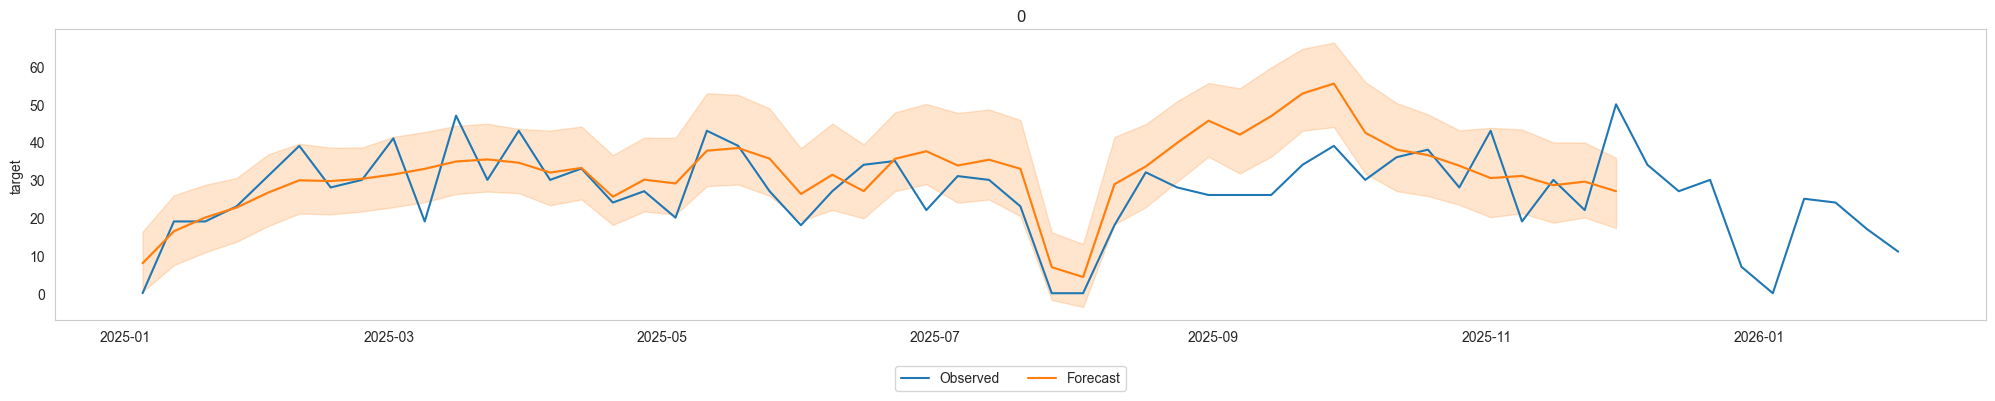

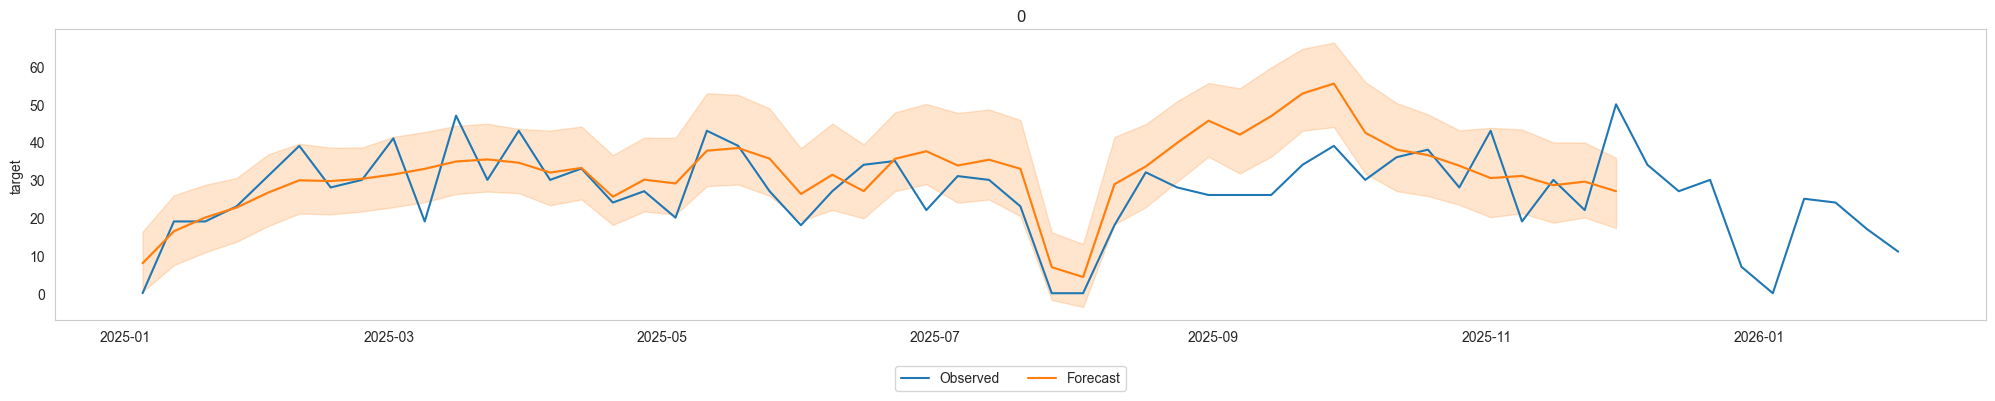

In [18]:
predictions = predictor_holiday.predict(
    train_data_w_holiday,
    known_covariates=test_data_w_holiday,
)

predictor_holiday.plot(
    test_data_w_holiday,
    predictions,
    max_history_length=200,
    item_ids=[0],
)